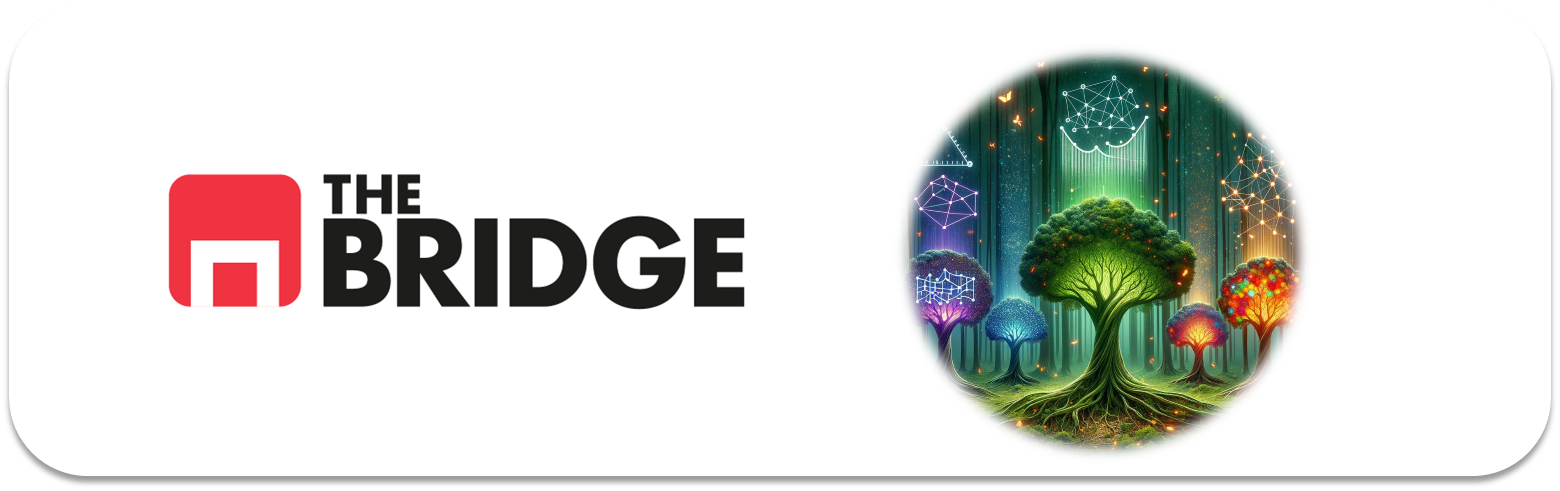

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import sklearn.metrics as metrics
import sklearn
import sklearn.datasets as datasets
import seaborn as sns
from sklearn.metrics import classification_report


### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [2]:
banco = pd.read_csv(r"C:\Users\pablo.moran\Documents\GitHub\DS-Online-Pablo-Moran\DS-Online-Pablo-Moran\04_Machine_Learning\Sprint_11\Unidad_01_ML_Supervisado_Arboles_de_Decision\03_Practica_Obligatoria\data\bank-full.csv", sep=";")

In [3]:
banco.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
banco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
banco.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
banco.describe(include="all")

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [13]:
banco.y.value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [9]:
target = "y"


In [10]:
for col in banco.columns:
    print(f"Para {col}, unkown o missing:", end=" ")
    try:
        missing = banco[col].value_counts()["unknown"]
        print(f"{missing} ({missing/len(banco)*100:.2f}%)")
    except:
        print("0 (0.00%)")

Para age, unkown o missing: 0 (0.00%)
Para job, unkown o missing: 288 (0.64%)
Para marital, unkown o missing: 0 (0.00%)
Para education, unkown o missing: 1857 (4.11%)
Para default, unkown o missing: 0 (0.00%)
Para balance, unkown o missing: 0 (0.00%)
Para housing, unkown o missing: 0 (0.00%)
Para loan, unkown o missing: 0 (0.00%)
Para contact, unkown o missing: 13020 (28.80%)
Para day, unkown o missing: 0 (0.00%)
Para month, unkown o missing: 0 (0.00%)
Para duration, unkown o missing: 0 (0.00%)
Para campaign, unkown o missing: 0 (0.00%)
Para pdays, unkown o missing: 0 (0.00%)
Para previous, unkown o missing: 0 (0.00%)
Para poutcome, unkown o missing: 36959 (81.75%)
Para y, unkown o missing: 0 (0.00%)


In [12]:
banco.shape

(45211, 17)

In [ ]:
banco.poutcome.value_counts(True)   #no serviría para nada

poutcome
unknown    0.817478
failure    0.108403
other      0.040698
success    0.033421
Name: proportion, dtype: float64

In [ ]:
banco.contact.value_counts(True)   #similar...

contact
cellular     0.647741
unknown      0.287983
telephone    0.064276
Name: proportion, dtype: float64

In [15]:
#analizar target
import bootcampviztools as bt


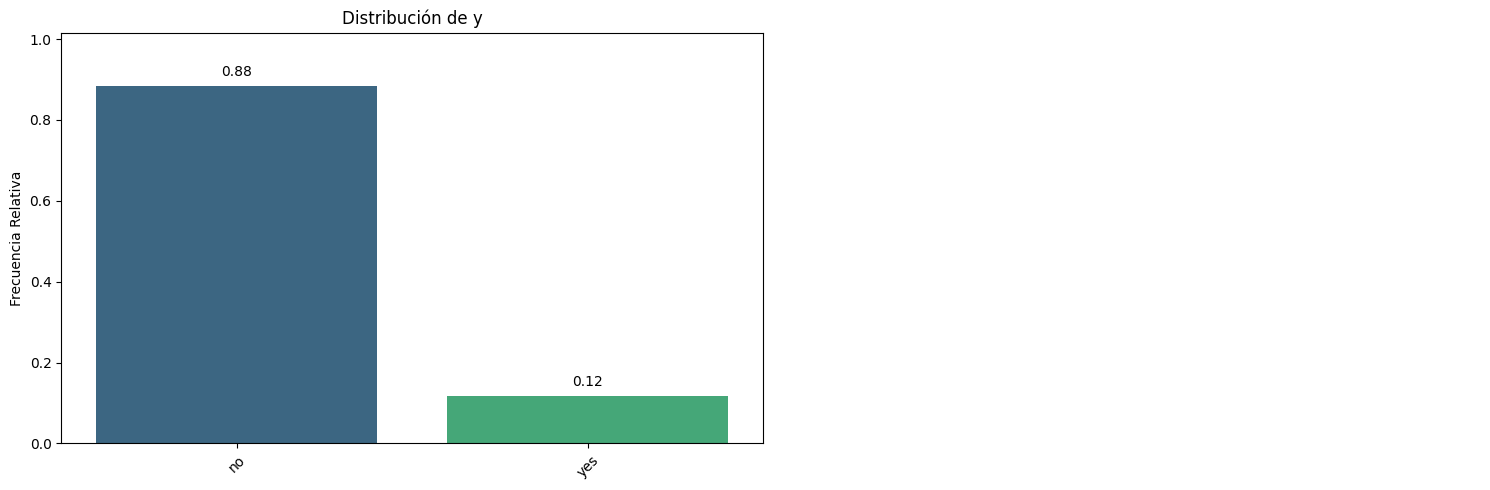

In [17]:
bt.pinta_distribucion_categoricas(banco, target, relativa=True, mostrar_valores=True)

In [21]:
banco[target].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

In [25]:
X = banco.drop(columns=target)
y = banco[target]

In [ ]:
#EL LO HACE CON TRAIN SET Y TEST SET

#from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(banco, test_size=0.2, random_state=42)

In [27]:
#tratamiento de variables categoricas
banco.select_dtypes(include='object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [28]:
import sklearn.preprocessing as preprocessing
variables_categoricas = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']



In [30]:
#variables numericas

variables_num = banco.select_dtypes(include=np.number).columns
variables_num

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

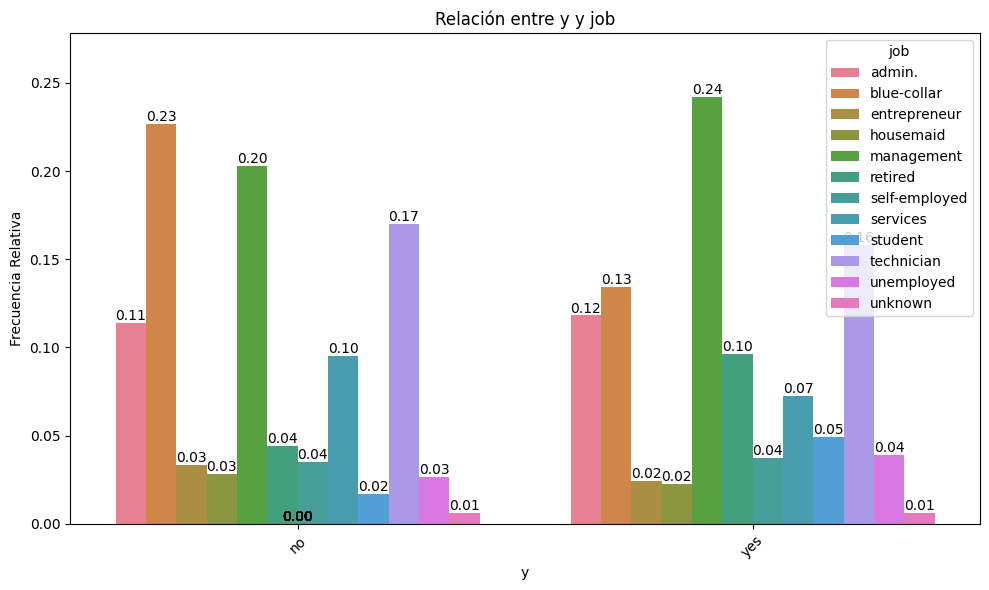

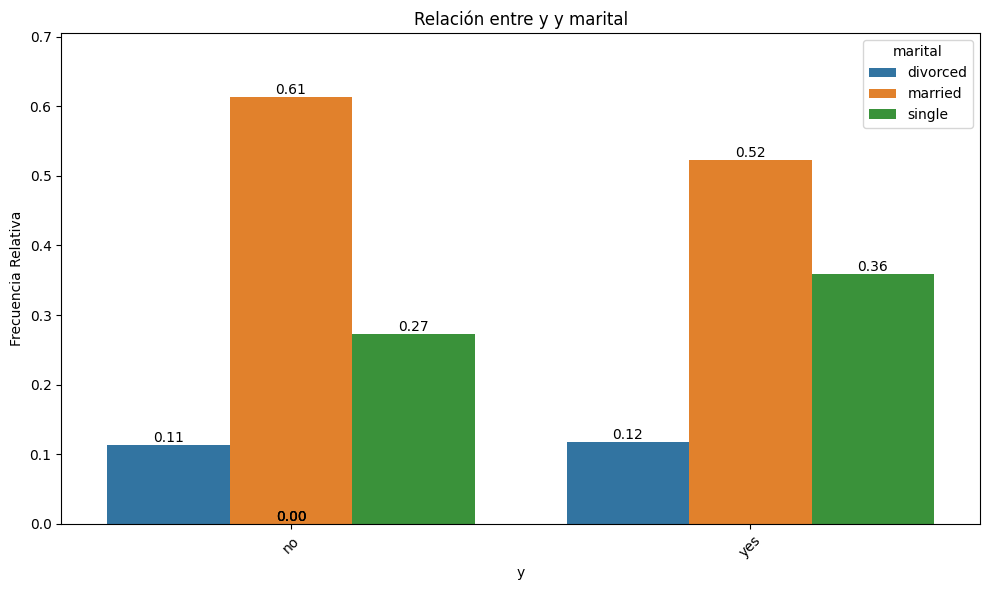

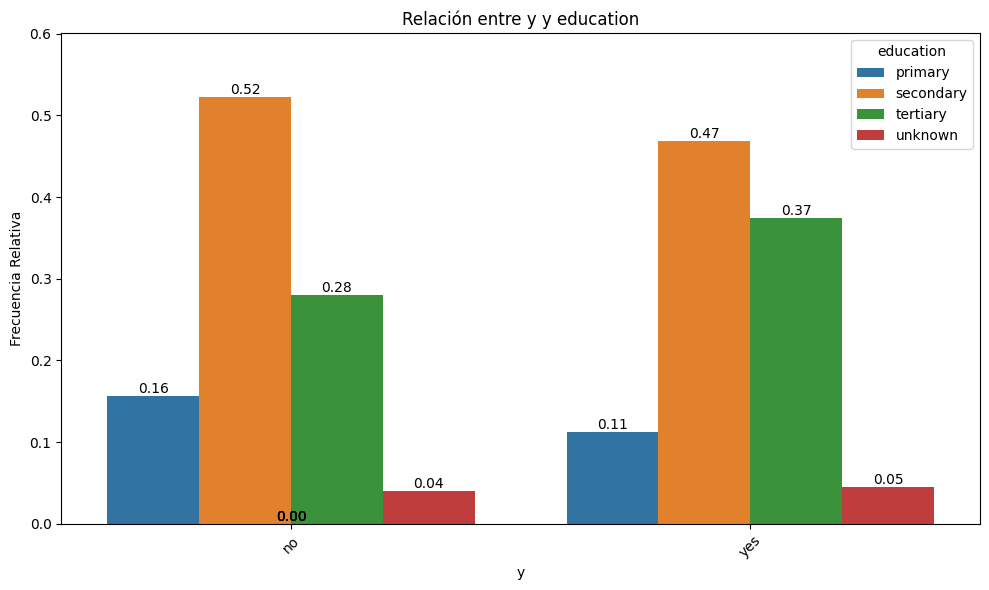

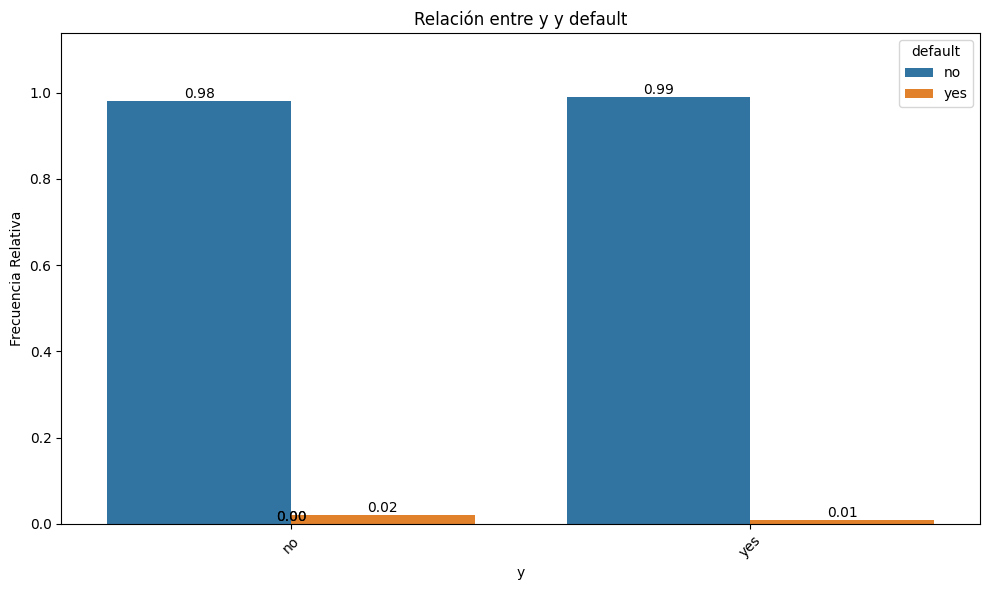

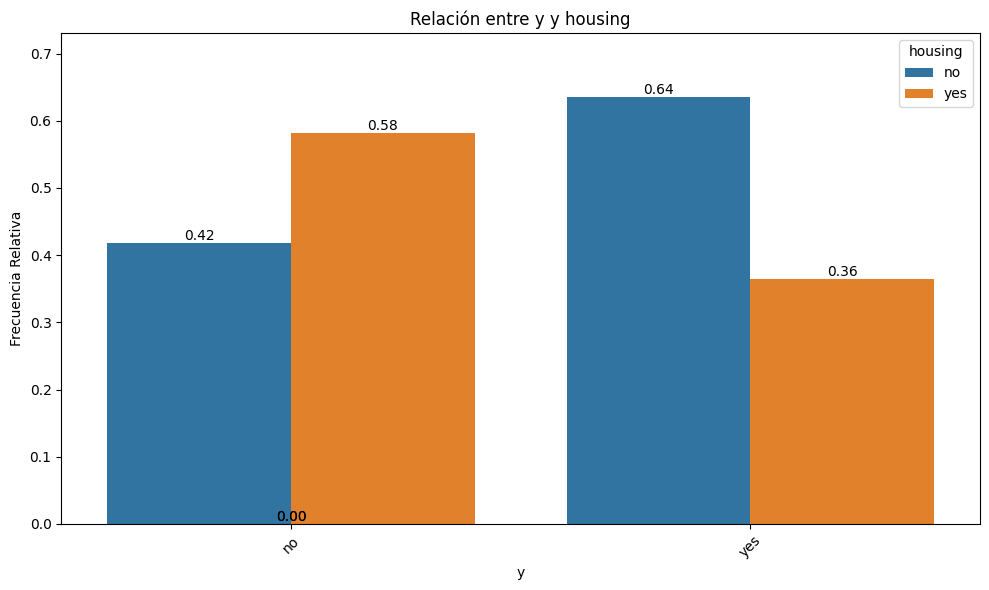

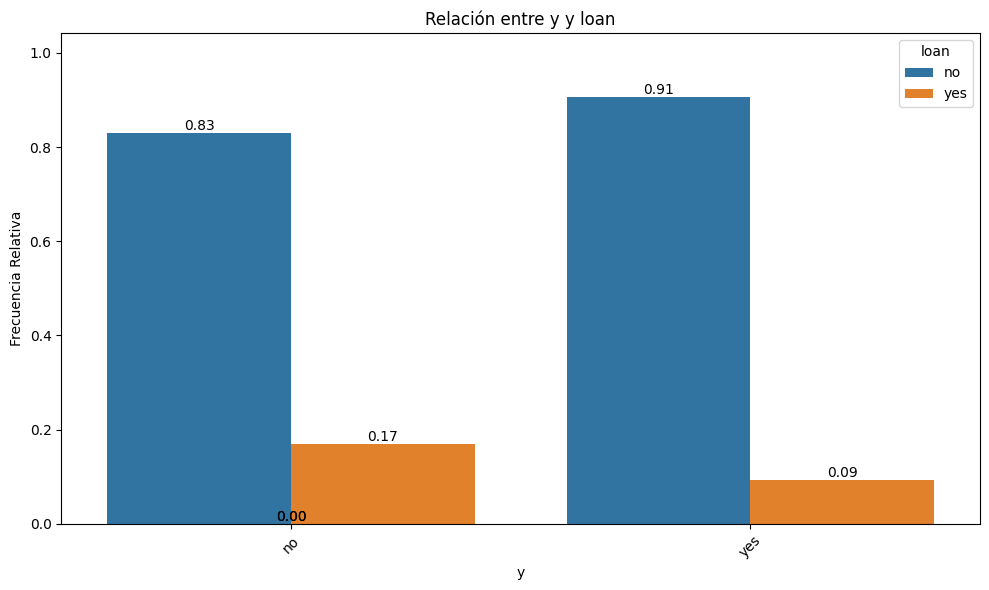

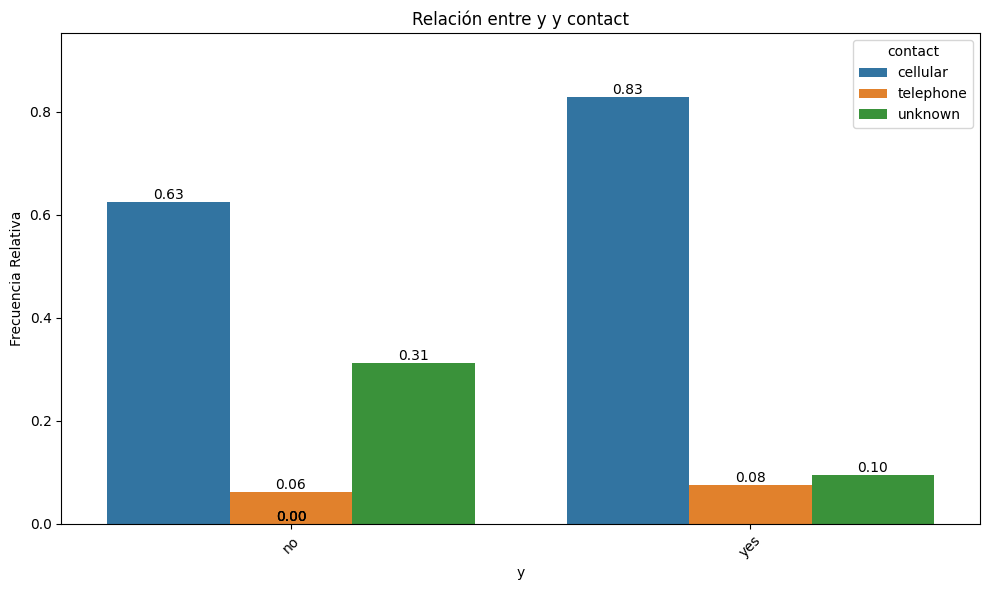

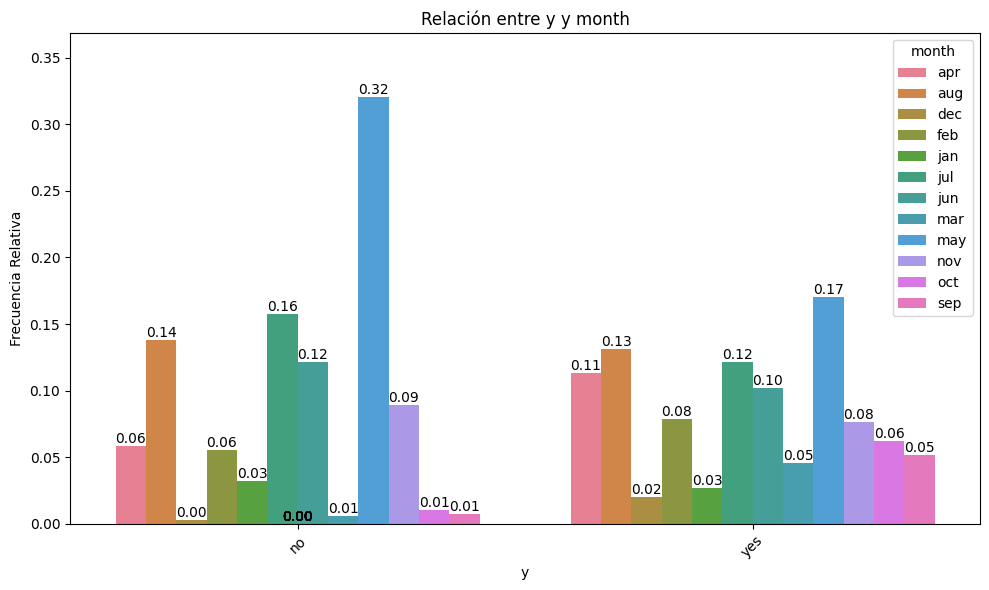

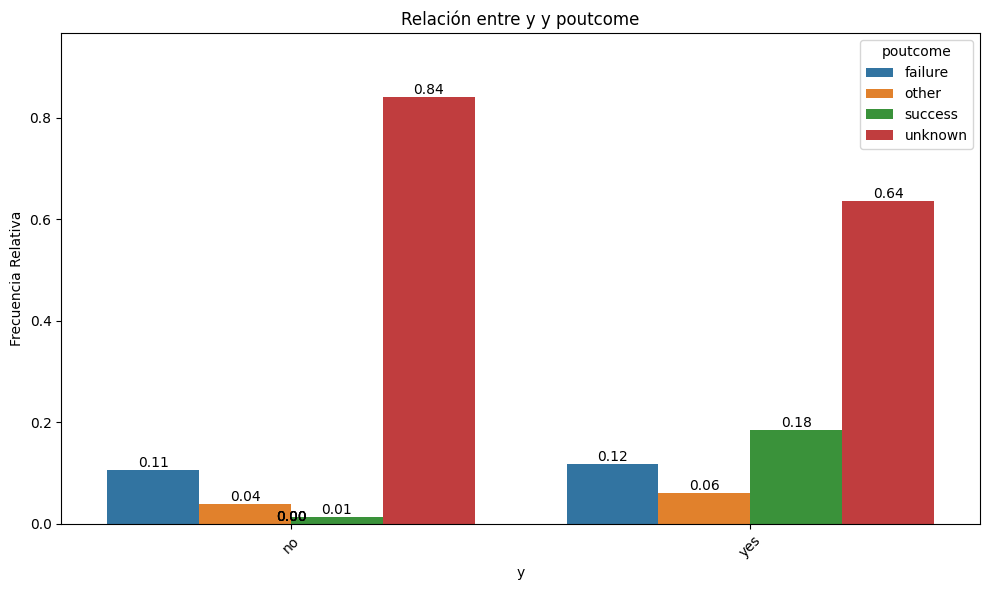

In [40]:
for col in variables_categoricas:
    bt.plot_categorical_relationship(train_set, target, col, relative_freq=True, show_values=True)
    plt.show()

In [44]:
#analizo lo de arriba si tiene relación... y me quito default

variables_categoricas


['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

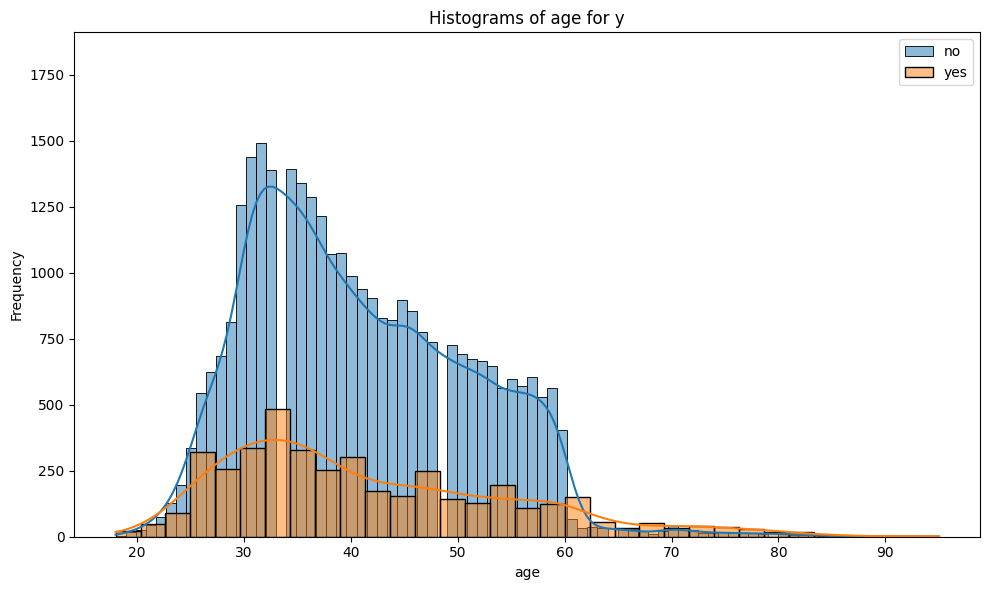

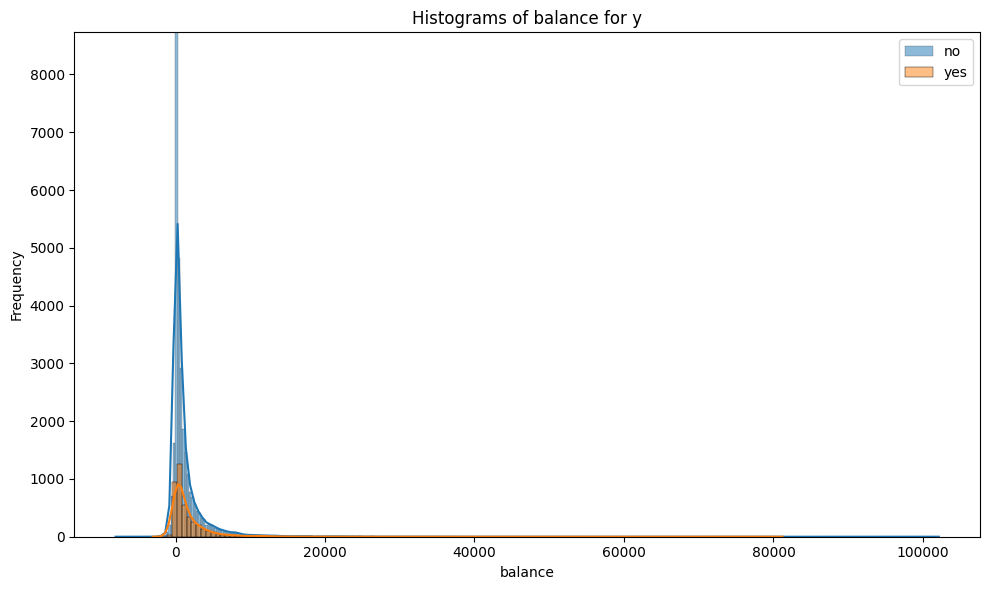

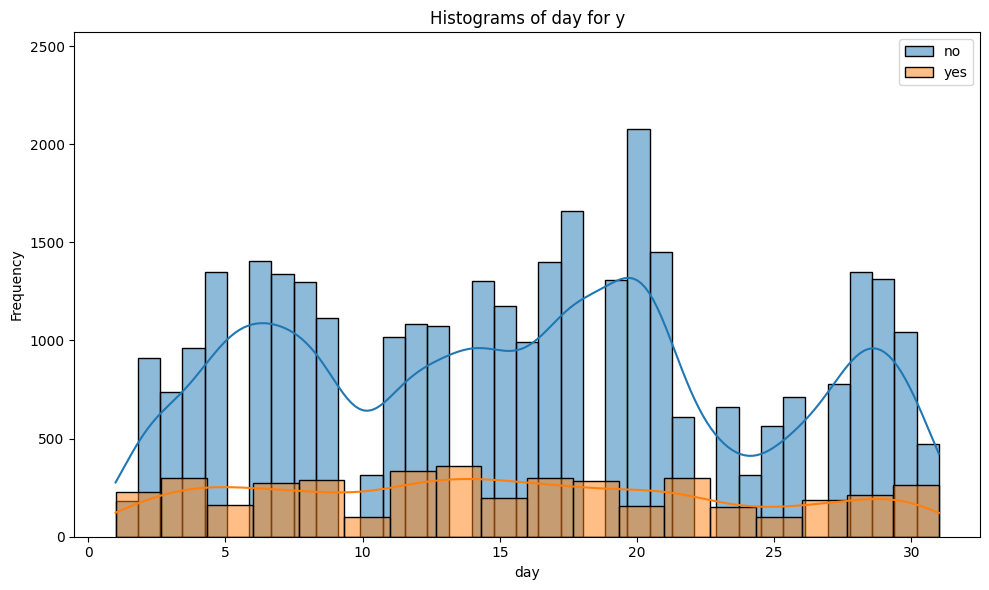

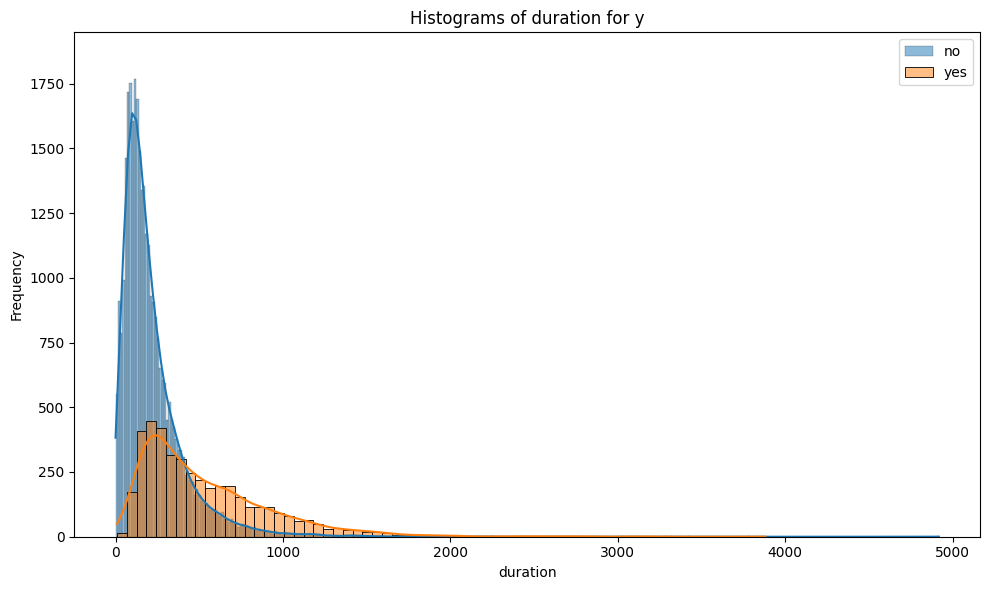

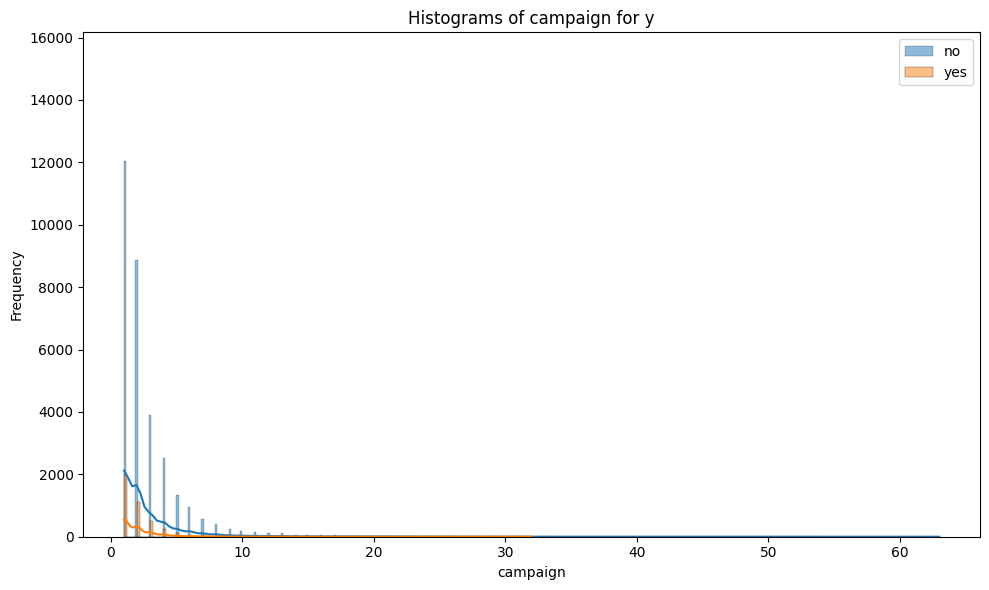

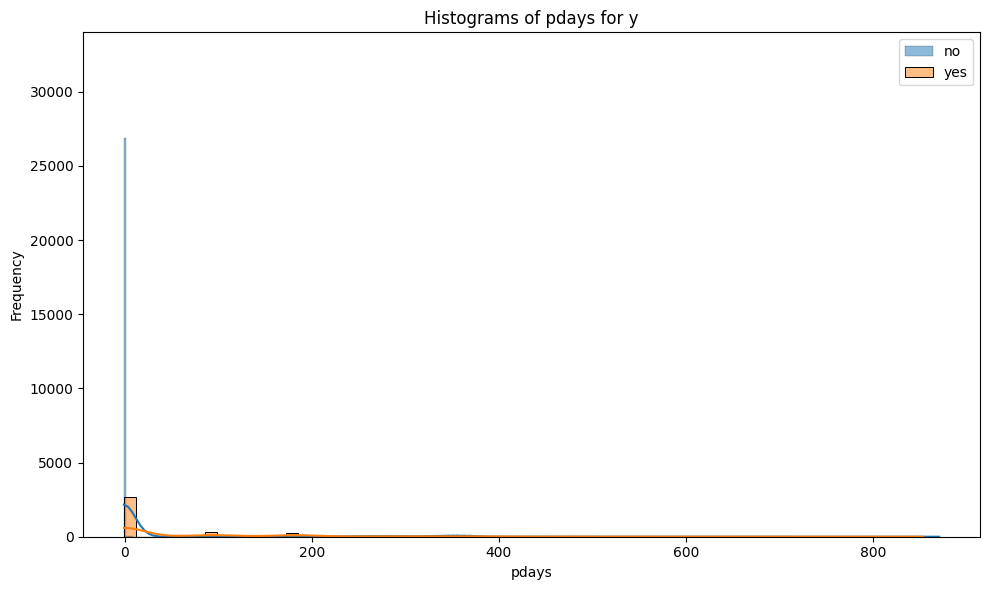

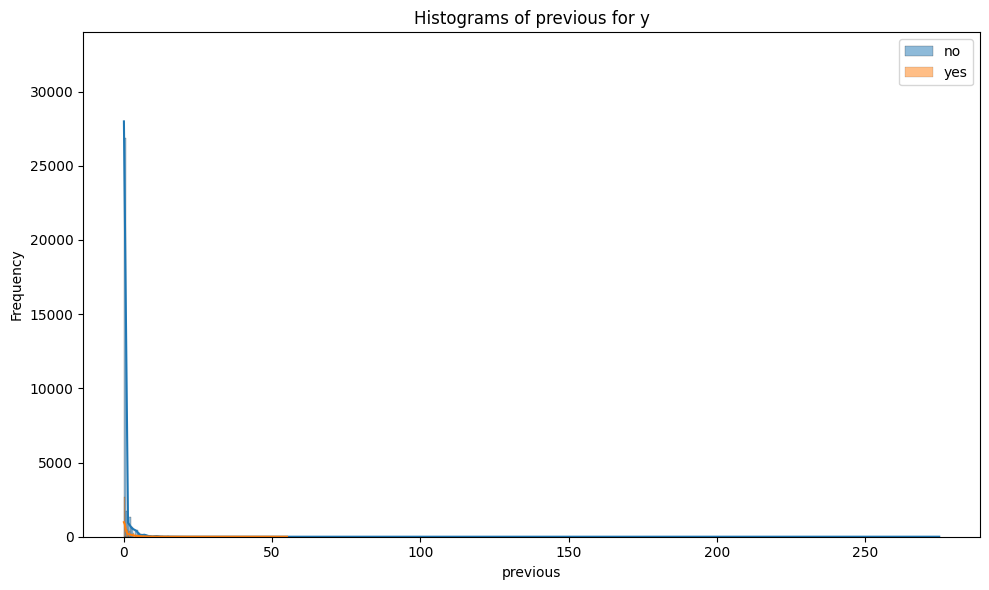

In [45]:
#vamos con las numericas

for col in variables_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col,group_size=2)
    plt.show()

In [47]:
train_set.balance.describe()

count     36168.000000
mean       1361.046146
std        3023.083187
min       -8019.000000
25%          70.000000
50%         447.000000
75%        1429.000000
max      102127.000000
Name: balance, dtype: float64

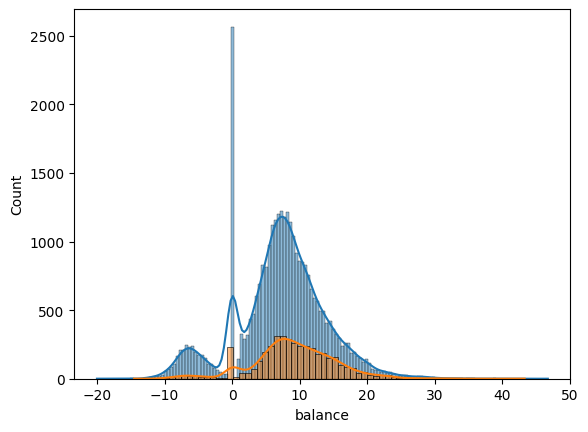

In [ ]:
col = "balance"   #aplicar raíz cúbica
sns.histplot(np.cbrt(train_set[col][train_set[target] == 'no']), kde=True)
sns.histplot(np.cbrt(train_set[col][train_set[target] == 'yes']), kde=True)
plt.show()

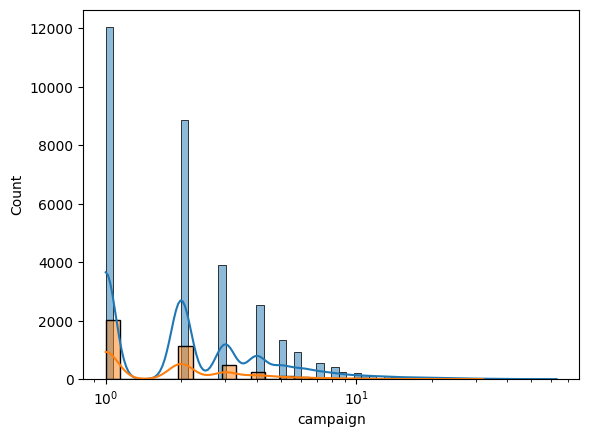

In [56]:
col = "campaign"   #aplicar raíz cúbica
sns.histplot(train_set[col][train_set[target] == 'no'], log_scale=10, kde=True)
sns.histplot(train_set[col][train_set[target] == 'yes'], log_scale=10, kde=True)
plt.show()

In [ ]:
#me quedo con todas las variables numéricas

In [57]:
train_set[variables_categoricas].nunique()

job          12
marital       3
education     4
housing       2
loan          2
contact       3
month        12
poutcome      4
dtype: int64

In [58]:
train_set['housing'] == 'yes'

3344      True
17965     True
18299    False
10221     True
32192    False
         ...  
11284    False
44732    False
38158     True
860      False
15795     True
Name: housing, Length: 36168, dtype: bool

In [59]:
train_set['housing'] = train_set['housing'] == 'yes'
train_set['loan'] = train_set['housing'] == 'yes'

In [60]:
test_set['housing'] = train_set['housing'] == 'yes'
test_set['loan'] = train_set['housing'] == 'yes'

In [62]:
variables_categoricas.remove('housing')
variables_categoricas.remove('loan')

In [64]:
#diccionario de meses

month_dict = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4, 
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12
    
    
    
}

In [65]:
train_set["month"] = train_set["month"].map(month_dict)
test_set["month"] = test_set["month"].map(month_dict)

In [66]:
variables_categoricas.remove("month")

In [67]:
train_set = pd.get_dummies(train_set, columns = variables_categoricas, dtype = int)
test_set = pd.get_dummies(test_set, columns = variables_categoricas, dtype = int)

In [68]:
train_set.shape

(36168, 38)

In [69]:
test_set.shape

(9043, 38)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

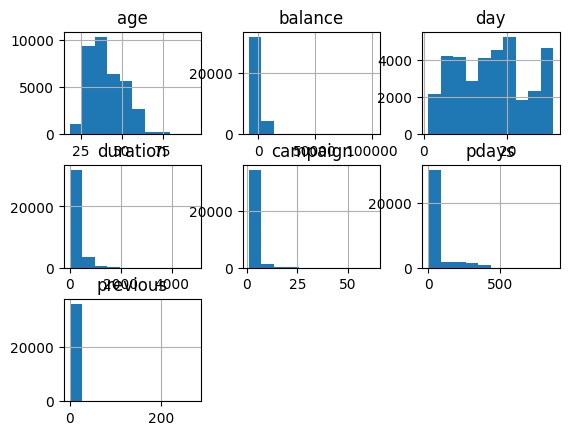

In [72]:
#numericas
train_set[variables_num].hist()
plt.tight_layout

In [73]:
train_set['pdays'] != -1

3344     False
17965    False
18299    False
10221    False
32192    False
         ...  
11284    False
44732     True
38158    False
860      False
15795    False
Name: pdays, Length: 36168, dtype: bool

In [74]:
train_set['contacted_before'] = train_set['pdays'] != -1
test_set['contacted_before'] = test_set['pdays'] != -1

In [75]:
train_set['contacted_before'].value_counts(normalize=True)

contacted_before
False    0.817186
True     0.182814
Name: proportion, dtype: float64

In [77]:
variables_categoricas.append('contacted_before')

In [79]:
#escalado
train_set_scaled = train_set
test_set_scaled = test_set

In [81]:
train_set_scaled['balance'] = np.cbrt(train_set_scaled["balance"])
train_set_scaled['duration'] = np.log(train_set_scaled["duration"] + 1)
train_set_scaled['campaign'] = np.log(train_set_scaled["campaign"])
train_set_scaled['pdays'] = np.log(train_set_scaled["pdays"]+2)
train_set_scaled['previous'] = np.log(train_set_scaled["previous"]+1)



In [82]:
test_set_scaled['balance'] = np.cbrt(test_set_scaled["balance"])
test_set_scaled['duration'] = np.log(test_set_scaled["duration"] + 1)
test_set_scaled['campaign'] = np.log(test_set_scaled["campaign"])
test_set_scaled['pdays'] = np.log(test_set_scaled["pdays"]+2)
test_set_scaled['previous'] = np.log(test_set_scaled["previous"]+1)


In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_set_scaled[variables_num] = train_set_scaled[variables_num].replace([np.inf, -np.inf], np.nan)
test_set_scaled[variables_num] = test_set_scaled[variables_num].replace([np.inf, -np.inf], np.nan)

# Rellenar NaN con la media de train
train_set_scaled[variables_num] = train_set_scaled[variables_num].fillna(train_set_scaled[variables_num].mean())
test_set_scaled[variables_num] = test_set_scaled[variables_num].fillna(train_set_scaled[variables_num].mean())
train_set_scaled[variables_num] = scaler.fit_transform(train_set_scaled[variables_num])
test_set_scaled[variables_num] = scaler.transform(test_set_scaled[variables_num])



In [86]:
train_set_scaled[variables_num]

,age,balance,day,duration,campaign,pdays,previous
3344,0.006515,0.451517,-0.098218,-0.855819,0.000000,0.000000,0.000000
17965,0.759937,0.553795,1.703422,0.491424,-1.222216,0.000000,0.000000
18299,0.100693,0.771368,1.823532,-0.214503,0.835733,0.000000,0.000000
10221,-0.370196,-2.707655,-0.578656,0.788385,2.462614,0.000000,0.000000
32192,1.419181,0.749894,-0.098218,0.474209,-1.222216,0.000000,0.000000
...,...,...,...,...,...,...,...
11284,0.289048,0.495058,0.262110,2.128063,0.000000,0.000000,0.000000
44732,-1.688684,0.354376,-0.938984,0.260197,0.000000,-1.667417,-2.899144
38158,-0.652729,0.539072,-0.098218,0.382100,0.000000,0.000000,0.000000
860,-0.746907,0.160078,-1.059093,-0.379441,0.000000,0.000000,0.000000


In [ ]:
variables_encoded_categoricas = []


In [20]:
for variable in variables_categoricas:
    X[variable] = le.fit_transform(X[variable])

In [21]:
y = le.fit_transform(y)

In [ ]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
#MINI EDA

X_train.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
count,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,40.930823,4.340909,1.168049,1.221992,0.018718,1361.046146,0.556708,0.161330,0.638382,15.817739,5.523501,256.891202,2.765649,40.180076,0.580264,2.560191
std,10.618369,3.273602,0.607385,0.746687,0.135530,3023.083187,0.496781,0.367841,0.897294,8.325860,3.003680,256.884103,3.120193,100.107617,2.370668,0.988095
min,18.000000,0.000000,0.000000,0.000000,0.000000,-8019.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,1.000000,1.000000,1.000000,0.000000,70.000000,0.000000,0.000000,0.000000,8.000000,3.000000,103.000000,1.000000,-1.000000,0.000000,3.000000
50%,39.000000,4.000000,1.000000,1.000000,0.000000,447.000000,1.000000,0.000000,0.000000,16.000000,6.000000,180.000000,2.000000,-1.000000,0.000000,3.000000
75%,48.000000,7.000000,2.000000,2.000000,0.000000,1429.000000,1.000000,0.000000,2.000000,21.000000,8.000000,318.000000,3.000000,-1.000000,0.000000,3.000000
max,95.000000,11.000000,2.000000,3.000000,1.000000,102127.000000,1.000000,1.000000,2.000000,31.000000,11.000000,4918.000000,63.000000,871.000000,275.000000,3.000000


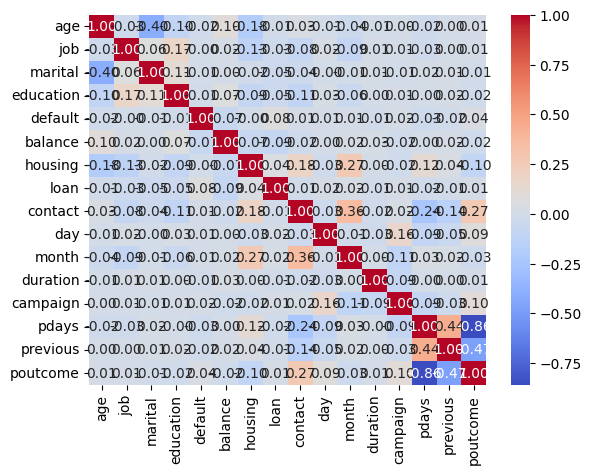

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [32]:
correlaciones = X_train.copy()
correlaciones['y'] = y_train
correlaciones.corr()['y'].sort_values(ascending=False)

y            1.000000
duration     0.393402
pdays        0.105742
previous     0.092051
education    0.062782
balance      0.052518
marital      0.043706
job          0.040499
age          0.026684
default     -0.023934
day         -0.025887
month       -0.027406
loan        -0.066708
campaign    -0.072571
poutcome    -0.080781
housing     -0.140234
contact     -0.150066
Name: y, dtype: float64

In [34]:
arbol_banco = sklearn.tree.DecisionTreeClassifier(class_weight='balanced')
arbol_banco.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [35]:
y_pred = arbol_banco.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      7952
           1       0.47      0.42      0.45      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.68      0.69      9043
weighted avg       0.87      0.87      0.87      9043



El 1 está muy bajo pero por estar desbalanceado


In [36]:
#GRID SEARCH CV
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree = sklearn.tree.DecisionTreeClassifier(class_weight='balanced')

grid_search = GridSearchCV(tree,
                           param_grid,
                           cv=5,
                           scoring='recall',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [37]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.8720832623871957


In [38]:
mejor_arbol = grid_search.best_estimator_
y_pred = mejor_arbol.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.68      0.80      7952
           1       0.28      0.87      0.42      1091

    accuracy                           0.71      9043
   macro avg       0.63      0.78      0.61      9043
weighted avg       0.89      0.71      0.76      9043



In [ ]:
# comparación con la regresión logística

In [39]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.59      0.16      0.26      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.57      0.60      9043
weighted avg       0.86      0.89      0.86      9043



c:\Users\pablo.moran\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
#DE los tres modelos saco estas conclusiones:

1. La regresión logística tiene la mejor accuracy pero es el peor modelo para el negocio — solo detecta el 16% de los clientes interesados. Prácticamente inútil para la campaña.
2. El árbol baseline es un punto intermedio mediocre.
3. El árbol optimizado es el ganador para este problema — sacrifica accuracy general pero detecta el 87% de los clientes potenciales, que es lo que le importa al banco.

1. ¿Qué modelo elegirías y por qué?   El árbol optimizado por lo indicado arriba
2. ¿Qué métrica has priorizado y por qué?  Recall. No podemos, como negocio, ''perder'' clientes potenciales.
3. ¿Qué limitaciones tiene el modelo? Sacrificamos accuracy en general. 